In [17]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
from brokenaxes import brokenaxes
import matplotlib.patches as patches
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter

In [18]:
fig_length = {1 : 3.50394,    # 1 column
              1.5 : 5.35433, # 1.5 columns
              2 : 7.20472}    # 2 columns
fig_height = 9.72441 # maximum height
fontsize_title = 9
fontsize_label = 8
fontsize_legend = 8
fontsize_axs = 8

plt.rcParams["figure.autolayout"] = True
plt.rcParams.update({'font.size' : 8})
plt.rcParams['font.family'] = 'Arial'

In [19]:
subdirectories = ['Hydrogen', 'Carbon dioxide', 'Ammonia', 'Methanol', 'Ethylene']
GWPFilePaths = [os.path.join('..', 'Results', 'GWP 20a', f'{subdir.lower()} climate change GWP 20a results.xlsx') for subdir in subdirectories]

In [20]:
for GWPFilePath in GWPFilePaths:
    
    dfs = pd.read_excel(GWPFilePath, sheet_name = None)
    dfAll = []

    for df in dfs.items():
        database = df[0]
        df = df[1]
        numCols = len(df.columns) - 1
        repeatedActivity = np.repeat(df['Activity'], numCols)
        dfNew = pd.DataFrame({
            'Activity' : repeatedActivity,
            'Location' : np.tile(df.columns[1:], len(df)),
            'GWP' : df.iloc[:, 1:].values.flatten(),
            'Database' : database
        })
        dfAll.append(dfNew)

    GWPDF = pd.concat(dfAll, ignore_index = True)
    GWPDF = GWPDF.sort_values('Activity')

    if 'hydrogen' in GWPFilePath:
        hydrogenGWPDF = GWPDF
        hydrogenBAUGWP = [row['GWP'] for index, row in hydrogenGWPDF.iterrows() if 'steam reforming' in row['Activity']
                                 and 'without electricity' in row['Activity']
                                 and 'GLO' in row['Location'] and '2020' in row['Database']
                                 and 'CCS' not in row['Activity'] and 'biomethane' not in row['Activity']][0]
    elif 'ammonia' in GWPFilePath:
        ammoniaGWPDF = GWPDF
        ammoniaBAUGWP = [row['GWP'] for index, row in ammoniaGWPDF.iterrows() if 'BAU' in row['Activity']
                                 and 'GLO' in row['Location'] and '2020' in row['Database']
                                 and 'CCS' not in row['Activity'] and 'fMTO' not in row['Activity']][0]
    elif 'methanol' in GWPFilePath:
        methanolGWPDF = GWPDF
        methanolBAUGWP = [row['GWP'] for index, row in methanolGWPDF.iterrows() if 'BAU' in row['Activity']
                                 and 'GLO' in row['Location'] and '2020' in row['Database']
                                 and 'CCS' not in row['Activity'] and 'fMTO' not in row['Activity']][0]
    elif 'ethylene' in GWPFilePath:
        ethyleneGWPDF = GWPDF
        ethyleneBAUGWP = [row['GWP'] for index, row in ethyleneGWPDF.iterrows() if 'BAU' in row['Activity']
                                 and 'GLO' in row['Location'] and '2020' in row['Database']
                                 and 'CCS' not in row['Activity'] and 'fMTO' not in row['Activity']][0]

In [21]:
locations = hydrogenGWPDF.sort_values('Location')['Location'].unique()

In [22]:
def replace_values(df):
    df = df.copy()
    df['Database'] = df['Database'].str.replace('Base', 'RCP6')
    df['Database'] = df['Database'].str.replace('PkBudg500', 'RCP19')
    df['Database'] = df['Database'].str.replace('PkBudg1150', 'RCP26')
    return df

hydrogenGWPDF = replace_values(hydrogenGWPDF)
# carbonDioxideGWPDF = replace_values(carbonDioxideGWPDF)
ammoniaGWPDF = replace_values(ammoniaGWPDF)
methanolGWPDF = replace_values(methanolGWPDF)
ethyleneGWPDF = replace_values(ethyleneGWPDF)

In [23]:
hydrogenGWPDF[['IAM', 'SSP', 'RCP', 'Year']] = hydrogenGWPDF['Database'].str.extract(r'(\w+)\s+(\w+)-(\w+)\s+(\d+)')
# carbonDioxideGWPDF[['IAM', 'SSP', 'RCP', 'Year']] = carbonDioxideGWPDF['Database'].str.extract(r'(\w+)\s+(\w+)-(\w+)\s+(\d+)')
ammoniaGWPDF[['IAM', 'SSP', 'RCP', 'Year']] = ammoniaGWPDF['Database'].str.extract(r'(\w+)\s+(\w+)-(\w+)\s+(\d+)')
methanolGWPDF[['IAM', 'SSP', 'RCP', 'Year']] = methanolGWPDF['Database'].str.extract(r'(\w+)\s+(\w+)-(\w+)\s+(\d+)')
ethyleneGWPDF[['IAM', 'SSP', 'RCP', 'Year']] = ethyleneGWPDF['Database'].str.extract(r'(\w+)\s+(\w+)-(\w+)\s+(\d+)')

hydrogenGWPDF['Pathway'] = hydrogenGWPDF['IAM'] + ' ' + hydrogenGWPDF['SSP'] + ' ' + hydrogenGWPDF['RCP']
# carbonDioxideGWPDF['Pathway'] = carbonDioxideGWPDF['IAM'] + ' ' + carbonDioxideGWPDF['SSP'] + ' ' + carbonDioxideGWPDF['RCP']
ammoniaGWPDF['Pathway'] = ammoniaGWPDF['IAM'] + ' ' + ammoniaGWPDF['SSP'] + ' ' + ammoniaGWPDF['RCP']
methanolGWPDF['Pathway'] = methanolGWPDF['IAM'] + ' ' + methanolGWPDF['SSP'] + ' ' + methanolGWPDF['RCP']
ethyleneGWPDF['Pathway'] = ethyleneGWPDF['IAM'] + ' ' + ethyleneGWPDF['SSP'] + ' ' + ethyleneGWPDF['RCP']

In [24]:
hydrogenBAUGWPDF = hydrogenGWPDF.loc[hydrogenGWPDF['Activity'].str.contains('hydrogen production, steam methane reforming of natural gas, 25 bar')]
hydrogenBlueGWPDF = hydrogenGWPDF.loc[hydrogenGWPDF['Activity'].str.contains(r'hydrogen production, steam methane reforming of natural gas, with CCS \(MDEA, 98% eff.\), 25 bar')]
hydrogenWindGWPDF = hydrogenGWPDF.loc[hydrogenGWPDF['Activity'].str.contains('hydrogen production, gaseous, 200 bar, from PEM electrolysis, from onshore wind electricity')]
hydrogenSolarGWPDF = hydrogenGWPDF.loc[hydrogenGWPDF['Activity'].str.contains('hydrogen production, gaseous, 200 bar, from PEM electrolysis, from solar electricity')]

hydrogenBAUGLOGWPDF = hydrogenBAUGWPDF[hydrogenBAUGWPDF['Location'] == 'GLO']
hydrogenBlueGLOGWPDF = hydrogenBlueGWPDF[hydrogenBlueGWPDF['Location'] == 'GLO']
hydrogenWindGLOGWPDF = hydrogenWindGWPDF[hydrogenWindGWPDF['Location'] == 'GLO']
hydrogenSolarGLOGWPDF = hydrogenSolarGWPDF[hydrogenSolarGWPDF['Location'] == 'GLO']

In [25]:
hydrogenBAUWOElecGWPDF = hydrogenGWPDF.loc[hydrogenGWPDF['Activity'].str.contains('hydrogen production without electricity, steam reforming of natural gas, 25 bar')]
hydrogenBlueWOElecGWPDF = hydrogenGWPDF.loc[hydrogenGWPDF['Activity'].str.contains(r'hydrogen production without electricity, steam methane reforming of natural gas, with CCS \(MDEA, 98% eff.\), 25 bar')]

hydrogenBAUWOElecGLOGWPDF = hydrogenBAUWOElecGWPDF[hydrogenBAUWOElecGWPDF['Location'] == 'GLO']
hydrogenBlueWOElecGLOGWPDF = hydrogenBlueWOElecGWPDF[hydrogenBlueWOElecGWPDF['Location'] == 'GLO']

In [26]:
ammoniaBAUGWPDF = ammoniaGWPDF.loc[ammoniaGWPDF['Activity'].str.contains('ammonia, BAU')]
ammoniaBlueGWPDF = ammoniaGWPDF.loc[ammoniaGWPDF['Activity'].str.contains('ammonia, blue')]
ammoniaWindGWPDF = ammoniaGWPDF.loc[ammoniaGWPDF['Activity'].str.contains('ammonia; hydrogen, PEM electrolysis, electricity onshore wind')]
ammoniaSolarGWPDF = ammoniaGWPDF.loc[ammoniaGWPDF['Activity'].str.contains('ammonia; hydrogen, PEM electrolysis, electricity solar')]

ammoniaBAUGLOGWPDF = ammoniaBAUGWPDF[ammoniaBAUGWPDF['Location'] == 'GLO']
ammoniaBlueGLOGWPDF = ammoniaBlueGWPDF[ammoniaBlueGWPDF['Location'] == 'GLO']
ammoniaWindGLOGWPDF = ammoniaWindGWPDF[ammoniaWindGWPDF['Location'] == 'GLO']
ammoniaSolarGLOGWPDF = ammoniaSolarGWPDF[ammoniaSolarGWPDF['Location'] == 'GLO']

In [27]:
methanolBAUGWPDF = methanolGWPDF.loc[methanolGWPDF['Activity'].str.contains('methanol, BAU')]
methanolBlueGWPDF = methanolGWPDF.loc[methanolGWPDF['Activity'].str.contains('methanol, blue')]
methanolWindGWPDF = methanolGWPDF.loc[methanolGWPDF['Activity'].str.contains('methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from onshore wind electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
methanolSolarGWPDF = methanolGWPDF.loc[methanolGWPDF['Activity'].str.contains('methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from solar electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]

methanolBAUGLOGWPDF = methanolBAUGWPDF[methanolBAUGWPDF['Location'] == 'GLO']
methanolBlueGLOGWPDF = methanolBlueGWPDF[methanolBlueGWPDF['Location'] == 'GLO']
methanolWindGLOGWPDF = methanolWindGWPDF[methanolWindGWPDF['Location'] == 'GLO']
methanolSolarGLOGWPDF = methanolSolarGWPDF[methanolSolarGWPDF['Location'] == 'GLO']

In [28]:
ethyleneBAUGWPDF = ethyleneGWPDF.loc[ethyleneGWPDF['Activity'].str.contains('ethylene, MTO; methanol, BAU')]
ethyleneBlueGWPDF = ethyleneGWPDF.loc[ethyleneGWPDF['Activity'].str.contains('ethylene, MTO; methanol, blue')]
ethyleneWindGWPDF = ethyleneGWPDF.loc[ethyleneGWPDF['Activity'].str.contains('ethylene, MTO; methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from onshore wind electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
ethyleneSolarGWPDF = ethyleneGWPDF.loc[ethyleneGWPDF['Activity'].str.contains('ethylene, MTO; methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from solar electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]

ethyleneBAUGLOGWPDF = ethyleneBAUGWPDF[ethyleneBAUGWPDF['Location'] == 'GLO']
ethyleneBlueGLOGWPDF = ethyleneBlueGWPDF[ethyleneBlueGWPDF['Location'] == 'GLO']
ethyleneWindGLOGWPDF = ethyleneWindGWPDF[ethyleneWindGWPDF['Location'] == 'GLO']
ethyleneSolarGLOGWPDF = ethyleneSolarGWPDF[ethyleneSolarGWPDF['Location'] == 'GLO']

In [29]:
def plot(df, marker, facecolor, edgecolor, polycolor, ax, markerSize):
    for pathway in pathways:
        dfPathway = df.loc[df['Pathway'] == pathway].sort_values('Year')
        colorRCP = colors[dfPathway.iloc[0]['RCP']]
        colorRCPDark = colorsDark[dfPathway.iloc[0]['RCP']]
        linestyle = linestyles[dfPathway.iloc[0]['RCP']]
        IAM = dfPathway.iloc[0]['IAM']
        SSP = dfPathway.iloc[0]['SSP']
        if SSP == 'SSP2' and IAM == 'image':
            color = edgecolor
            linewidth = 1.5
        else:
            color = edgecolor
            linewidth = 0.5
        if SSP == 'SSP2':
            ax.plot(years[0:2], np.array([min(df[df['Year'] == years[0]]['GWP']), dfPathway[dfPathway['Year'] == '2030']['GWP']], dtype = object), 
                    color = color, zorder = 1, linewidth = linewidth, linestyle = linestyle)
            ax.plot(years[1:], dfPathway[dfPathway['Year'] != '2020']['GWP'], color = color, zorder = 1, linewidth = linewidth, linestyle = linestyle)
        #plt.scatter(years[0:2], np.array([min(df[df['Year'] == years[0]]['GWP']), dfPathway[dfPathway['Year'] == '2030']['GWP']], dtype = object), 
        #            facecolor = facecolor, edgecolor = edgecolor, marker = marker, s  = 15, zorder = 2)
        #plt.scatter(years[1:], dfPathway[dfPathway['Year'] != '2020']['GWP'], 
        #            facecolor = 'white', edgecolor = color, marker = marker, s  = 15, zorder = 2)

    if markerSize == 0:
        ax.scatter(years[0], min(df[df['Year'] == years[0]]['GWP']), facecolor = facecolor, edgecolor = edgecolor, marker = marker, s = 60, zorder = 2)
    else:
        ax.scatter(years[0], min(df[df['Year'] == years[0]]['GWP']), facecolor = facecolor, edgecolor = edgecolor, marker = marker, s = markerSize, zorder = 2)

    for x in range(0, len(years) - 1):
        dfTemp = df[df['SSP'] == 'SSP2']
        x_values = [x, x + 1, x + 1, x]
        y_values = np.array([min(dfTemp[dfTemp['Year'] == years[x]]['GWP']), min(dfTemp[dfTemp['Year'] == years[x + 1]]['GWP']), 
                            max(dfTemp[dfTemp['Year'] == years[x + 1]]['GWP']), max(dfTemp[dfTemp['Year'] == years[x]]['GWP'])])
        polygon = patches.Polygon(xy = list(zip(x_values, y_values)), facecolor = polycolor, alpha = 0.3, zorder = 0)
        ax.add_patch(polygon)

In [30]:
pathways = hydrogenBAUGWPDF['Pathway'].unique()
colors = {'RCP6' : '#fb7b71', 'RCP26' : '#e1d055', 'RCP19' : '#6abb4d'}
colorsDark = {'RCP6' : '#fa5649', 'RCP26' : '#d9c429', 'RCP19' : '#3d6f2b'}
linestyles = {'RCP6' : '-', 'RCP26' : '-.', 'RCP19' : '--'}
years = ['2020', '2030', '2040', '2050']

In [31]:
"""fig, (ax1, ax2) = plt.subplots(2, 1, sharex = True, figsize = (fig_length[1.5], fig_height*0.4), gridspec_kw={'height_ratios': [1, 4]})
fig.subplots_adjust(hspace = 0) 

plot(hydrogenBAUGLOGWPDF, 'o', '#d8d8d8', 'black', '#808080', ax1)
ax1.set_ylim([9.9, 11.1])

plot(hydrogenBlueGLOGWPDF, 'd', '#A78DD8', '#52318E', '#A78DD8', ax2)
plot(hydrogenWindGLOGWPDF, '^', '#6DD2EA', '#167F99', '#6DD2EA', ax2)
plot(hydrogenSolarGLOGWPDF, 'h', '#FB7B71', '#B71205', '#FB7B71', ax2)

ax1.spines.bottom.set_visible(False)
ax2.spines.top.set_visible(False)
ax1.xaxis.set_ticks_position('none')
ax1.tick_params(labeltop = False)  # don't put tick labels at the top
ax2.xaxis.tick_bottom()

d = 0  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize = 5,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax1.plot([0, 1], [0, 0], transform = ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform = ax2.transAxes, **kwargs)

ax2.set_ylabel('GWP [kg CO$_\mathrm{2}$-eq kg$^\mathrm{-1}$]')

legend_elements1 = [Line2D([0], [0], color = "#000000", linestyle = "-",
                                             label = 'Image\nRCP6', linewidth = 1.5),
                    Line2D([0], [0], color = "#000000", linestyle = "-.",
                                             label = 'Image\nRCP2.6', linewidth = 1.5),
                    Line2D([0], [0], color = "#000000", linestyle = "--",
                                             label = 'Image\nRCP1.9', linewidth = 1.5),
                    Line2D([0], [0], color = "#000000", linestyle = "-",
                                             label = 'Remind\nRCP6', linewidth = 0.5),
                    Line2D([0], [0], color = "#000000", linestyle = "-.",
                                             label = 'Remind\nRCP2.6', linewidth = 0.5),
                    Line2D([0], [0], color = "#000000", linestyle = "--",
                                             label = 'Remind\nRCP1.9', linewidth = 0.5),]

legend_elements2 = [Line2D([0], [0], marker = 'o', color = "none", 
                                             markerfacecolor ='#d8d8d8', markeredgecolor = "#000000",
                                             label = 'Fossil', markersize = 4),
                   Line2D([0], [0], marker = 'd', color = "none", 
                                             markerfacecolor ='#A78DD8', markeredgecolor = "#52318E",
                                             label = 'Blue', markersize = 5),
                   Line2D([0], [0], marker = 'h', color = "none", 
                                             markerfacecolor ='#FB7B71', markeredgecolor = "#B71205",
                                             label = 'Solar', markersize = 5),
                   Line2D([0], [0], marker = '^', color = "none", 
                                             markerfacecolor ='#6DD2EA', markeredgecolor = "#167F99",
                                             label = 'Wind', markersize = 5),]

legend1 = fig.legend(handles = legend_elements1, frameon = False, loc = "upper center", ncol = 6, 
          prop={"size":8}, bbox_to_anchor=(0.53, 0.02), handletextpad = 0.1)

legend2 = fig.legend(handles = legend_elements2, frameon = False, loc = "center left", ncol = 1, 
          prop={"size":8}, bbox_to_anchor=(0.1, 0.2), handletextpad = 0.1)

for label in legend1.get_texts():
    label.set_ha('center')

for i in range(len(legend1.legend_handles)):
    handle = legend1.legend_handles[i]
    handle.set_xdata([0, 4, 14])

plotPathPNG = os.path.join('..', 'Plots', 'Phase 2', 'GWP', 'Hydrogen SSP2 GLO.png')
plotPathSVG = os.path.join('..', 'Plots', 'Phase 2', 'GWP', 'Hydrogen SSP2 GLO.svg')
plt.savefig(plotPathPNG, dpi = 600, format = 'png', bbox_inches = 'tight', facecolor = 'w')
plt.savefig(plotPathSVG, dpi = 600, format = 'svg', bbox_inches = 'tight', facecolor = 'w')"""

'fig, (ax1, ax2) = plt.subplots(2, 1, sharex = True, figsize = (fig_length[1.5], fig_height*0.4), gridspec_kw={\'height_ratios\': [1, 4]})\nfig.subplots_adjust(hspace = 0) \n\nplot(hydrogenBAUGLOGWPDF, \'o\', \'#d8d8d8\', \'black\', \'#808080\', ax1)\nax1.set_ylim([9.9, 11.1])\n\nplot(hydrogenBlueGLOGWPDF, \'d\', \'#A78DD8\', \'#52318E\', \'#A78DD8\', ax2)\nplot(hydrogenWindGLOGWPDF, \'^\', \'#6DD2EA\', \'#167F99\', \'#6DD2EA\', ax2)\nplot(hydrogenSolarGLOGWPDF, \'h\', \'#FB7B71\', \'#B71205\', \'#FB7B71\', ax2)\n\nax1.spines.bottom.set_visible(False)\nax2.spines.top.set_visible(False)\nax1.xaxis.set_ticks_position(\'none\')\nax1.tick_params(labeltop = False)  # don\'t put tick labels at the top\nax2.xaxis.tick_bottom()\n\nd = 0  # proportion of vertical to horizontal extent of the slanted line\nkwargs = dict(marker=[(-1, -d), (1, d)], markersize = 5,\n              linestyle="none", color=\'k\', mec=\'k\', mew=1, clip_on=False)\nax1.plot([0, 1], [0, 0], transform = ax1.transAxes, **kw

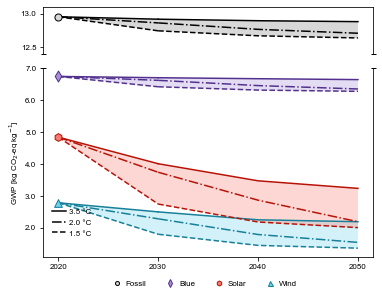

In [32]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex = True, figsize = (fig_length[1.5], fig_height*0.4), gridspec_kw={'height_ratios': [1, 4]})
fig.subplots_adjust(hspace = 0) 

plot(hydrogenBAUWOElecGLOGWPDF, 'o', '#d8d8d8', 'black', '#808080', ax1, 50)
ax1.set_ylim([12.4, 13.1])
ax1.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

plot(hydrogenBlueWOElecGLOGWPDF, 'd', '#A78DD8', '#52318E', '#A78DD8', ax2, 0)
plot(hydrogenWindGLOGWPDF, '^', '#6DD2EA', '#167F99', '#6DD2EA', ax2, 0)
plot(hydrogenSolarGLOGWPDF, 'h', '#FB7B71', '#B71205', '#FB7B71', ax2, 0)
ax2.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

ax1.spines.bottom.set_visible(False)
ax2.spines.top.set_visible(False)
ax1.xaxis.set_ticks_position('none')
ax1.tick_params(labeltop = False)  # don't put tick labels at the top
ax2.xaxis.tick_bottom()

d = 0  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize = 5,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax1.plot([0, 1], [0, 0], transform = ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform = ax2.transAxes, **kwargs)

ax2.set_ylabel('GWP [kg CO$_\mathrm{2}$-eq kg$^\mathrm{-1}$]')

legend_elements1 = [Line2D([0], [0], color = "#000000", linestyle = "-",
                                             label = '3.5 °C', linewidth = 1.5),
                    Line2D([0], [0], color = "#000000", linestyle = "-.",
                                             label = '2.0 °C', linewidth = 1.5),
                    Line2D([0], [0], color = "#000000", linestyle = "--",
                                             label = '1.5 °C', linewidth = 1.5),]

legend_elements2 = [Line2D([0], [0], marker = 'o', color = "none", 
                                             markerfacecolor ='#d8d8d8', markeredgecolor = "#000000",
                                             label = 'Fossil', markersize = 4),
                   Line2D([0], [0], marker = 'd', color = "none", 
                                             markerfacecolor ='#A78DD8', markeredgecolor = "#52318E",
                                             label = 'Blue', markersize = 5),
                   Line2D([0], [0], marker = 'h', color = "none", 
                                             markerfacecolor ='#FB7B71', markeredgecolor = "#B71205",
                                             label = 'Solar', markersize = 5),
                   Line2D([0], [0], marker = '^', color = "none", 
                                             markerfacecolor ='#6DD2EA', markeredgecolor = "#167F99",
                                             label = 'Wind', markersize = 5),]

legend1 = fig.legend(handles = legend_elements2, frameon = False, loc = "upper center", ncol = 4, 
          prop={"size":8}, bbox_to_anchor=(0.53, 0.02), handletextpad = 0.1)

legend2 = fig.legend(handles = legend_elements1, frameon = False, loc = "center left", ncol = 1, 
          prop={"size":8}, bbox_to_anchor=(0.12, 0.2), handletextpad = 0.1)

for i in range(len(legend2.legend_handles)):
    handle = legend2.legend_handles[i]
    handle.set_xdata([0, 4, 14])

plotPathPNG = os.path.join('..', 'Plots', 'Phase 2', 'GWP 20a', 'Hydrogen image SSP2 GLO.png')
plotPathSVG = os.path.join('..', 'Plots', 'Phase 2', 'GWP 20a', 'Hydrogen image SSP2 GLO.svg')
plt.savefig(plotPathPNG, dpi = 600, format = 'png', bbox_inches = 'tight', facecolor = 'w')
plt.savefig(plotPathSVG, dpi = 600, format = 'svg', bbox_inches = 'tight', facecolor = 'w')

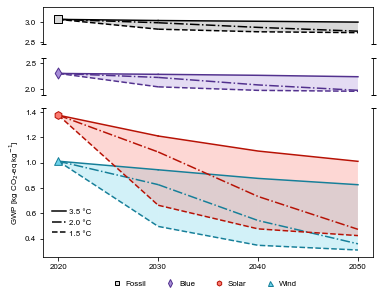

In [33]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex = True, figsize = (fig_length[1.5], fig_height*0.4), gridspec_kw={'height_ratios': [1, 1, 4]})
fig.subplots_adjust(hspace = 0)

plot(ammoniaBAUGLOGWPDF, 's', '#d8d8d8', 'black', '#808080', ax1, 50)
ax1.set_ylim([2.78, 3.15])
ax1.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

plot(ammoniaBlueGLOGWPDF, 'd', '#A78DD8', '#52318E', '#A78DD8', ax2, 0)
ax2.set_ylim([1.9, 2.6])
ax2.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

plot(ammoniaWindGLOGWPDF, '^', '#6DD2EA', '#167F99', '#6DD2EA', ax3, 0)
plot(ammoniaSolarGLOGWPDF, 'h', '#FB7B71', '#B71205', '#FB7B71', ax3, 0)

ax1.spines.bottom.set_visible(False)
ax2.spines.top.set_visible(False)
ax1.xaxis.set_ticks_position('none')
ax1.tick_params(labeltop = False)  # don't put tick labels at the top
ax2.xaxis.tick_bottom()

ax2.spines.bottom.set_visible(False)
ax3.spines.top.set_visible(False)
ax2.xaxis.set_ticks_position('none')
ax2.tick_params(labeltop = False)  # don't put tick labels at the top
ax3.xaxis.tick_bottom()

d = 0  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize = 5,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax1.plot([0, 1], [0, 0], transform = ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform = ax2.transAxes, **kwargs)
ax2.plot([0, 1], [0, 0], transform = ax2.transAxes, **kwargs)
ax3.plot([0, 1], [1, 1], transform = ax3.transAxes, **kwargs)

ax3.set_ylabel('GWP [kg CO$_\mathrm{2}$-eq kg$^\mathrm{-1}$]')

legend_elements1 = [Line2D([0], [0], color = "#000000", linestyle = "-",
                                             label = '3.5 °C', linewidth = 1.5),
                    Line2D([0], [0], color = "#000000", linestyle = "-.",
                                             label = '2.0 °C', linewidth = 1.5),
                    Line2D([0], [0], color = "#000000", linestyle = "--",
                                             label = '1.5 °C', linewidth = 1.5),]

legend_elements2 = [Line2D([0], [0], marker = 's', color = "none", 
                                             markerfacecolor ='#d8d8d8', markeredgecolor = "#000000",
                                             label = 'Fossil', markersize = 4),
                   Line2D([0], [0], marker = 'd', color = "none", 
                                             markerfacecolor ='#A78DD8', markeredgecolor = "#52318E",
                                             label = 'Blue', markersize = 5),
                   Line2D([0], [0], marker = 'h', color = "none", 
                                             markerfacecolor ='#FB7B71', markeredgecolor = "#B71205",
                                             label = 'Solar', markersize = 5),
                   Line2D([0], [0], marker = '^', color = "none", 
                                             markerfacecolor ='#6DD2EA', markeredgecolor = "#167F99",
                                             label = 'Wind', markersize = 5),]

legend1 = fig.legend(handles = legend_elements2, frameon = False, loc = "upper center", ncol = 4, 
          prop={"size":8}, bbox_to_anchor=(0.53, 0.02), handletextpad = 0.1)

legend2 = fig.legend(handles = legend_elements1, frameon = False, loc = "center left", ncol = 1, 
          prop={"size":8}, bbox_to_anchor=(0.12, 0.2), handletextpad = 0.1)

for i in range(len(legend2.legend_handles)):
    handle = legend2.legend_handles[i]
    handle.set_xdata([0, 4, 14])

plotPathPNG = os.path.join('..', 'Plots', 'Phase 2', 'GWP 20a', 'Ammonia image SSP2 GLO.png')
plotPathSVG = os.path.join('..', 'Plots', 'Phase 2', 'GWP 20a', 'Ammonia image SSP2 GLO.svg')
plt.savefig(plotPathPNG, dpi = 600, format = 'png', bbox_inches = 'tight', facecolor = 'w')
plt.savefig(plotPathSVG, dpi = 600, format = 'svg', bbox_inches = 'tight', facecolor = 'w')

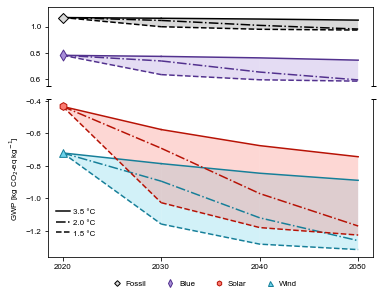

In [34]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex = True, figsize = (fig_length[1.5], fig_height*0.4), gridspec_kw={'height_ratios': [2, 4]})
fig.subplots_adjust(hspace = 0)

plot(methanolBAUGLOGWPDF, 'D', '#d8d8d8', 'black', '#808080', ax1, 50)
plot(methanolBlueGLOGWPDF, 'd', '#A78DD8', '#52318E', '#A78DD8', ax1, 0)
ax1.set_ylim([0.55, 1.15])

plot(methanolWindGLOGWPDF, '^', '#6DD2EA', '#167F99', '#6DD2EA', ax2, 0)
plot(methanolSolarGLOGWPDF, 'h', '#FB7B71', '#B71205', '#FB7B71', ax2, 0)

ax1.spines.bottom.set_visible(False)
ax2.spines.top.set_visible(False)
ax1.xaxis.set_ticks_position('none')
ax1.tick_params(labeltop = False)  # don't put tick labels at the top
ax2.xaxis.tick_bottom()

d = 0  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize = 5,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax1.plot([0, 1], [0, 0], transform = ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform = ax2.transAxes, **kwargs)

ax2.set_ylabel('GWP [kg CO$_\mathrm{2}$-eq kg$^\mathrm{-1}$]')

legend_elements1 = [Line2D([0], [0], color = "#000000", linestyle = "-",
                                             label = '3.5 °C', linewidth = 1.5),
                    Line2D([0], [0], color = "#000000", linestyle = "-.",
                                             label = '2.0 °C', linewidth = 1.5),
                    Line2D([0], [0], color = "#000000", linestyle = "--",
                                             label = '1.5 °C', linewidth = 1.5),]

legend_elements2 = [Line2D([0], [0], marker='D', color = "none", 
                                             markerfacecolor ='#d8d8d8', markeredgecolor = "#000000",
                                             label = 'Fossil', markersize = 4),
                   Line2D([0], [0], marker = 'd', color = "none", 
                                             markerfacecolor ='#A78DD8', markeredgecolor = "#52318E",
                                             label = 'Blue', markersize = 5),
                   Line2D([0], [0], marker='h', color = "none", 
                                             markerfacecolor ='#FB7B71', markeredgecolor = "#B71205",
                                             label = 'Solar', markersize = 5),
                   Line2D([0], [0], marker='^', color = "none", 
                                             markerfacecolor ='#6DD2EA', markeredgecolor = "#167F99",
                                             label = 'Wind', markersize = 5),]

legend1 = fig.legend(handles = legend_elements2, frameon = False, loc = "upper center", ncol = 4, 
          prop={"size":8}, bbox_to_anchor=(0.53, 0.02), handletextpad = 0.1)

legend2 = fig.legend(handles = legend_elements1, frameon = False, loc = "center left", ncol = 1, 
          prop={"size":8}, bbox_to_anchor=(0.13, 0.2), handletextpad = 0.1)

for i in range(len(legend2.legend_handles)):
    handle = legend2.legend_handles[i]
    handle.set_xdata([0, 4, 14])

plotPathPNG = os.path.join('..', 'Plots', 'Phase 2', 'GWP 20a', 'Methanol image SSP2 GLO.png')
plotPathSVG = os.path.join('..', 'Plots', 'Phase 2', 'GWP 20a', 'Methanol image SSP2 GLO.svg')
plt.savefig(plotPathPNG, dpi = 600, format = 'png', bbox_inches = 'tight', facecolor = 'w')
plt.savefig(plotPathSVG, dpi = 600, format = 'svg', bbox_inches = 'tight', facecolor = 'w')

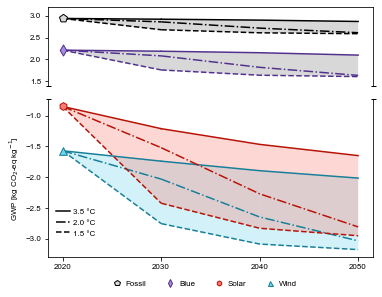

In [35]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex = True, figsize = (fig_length[1.5], fig_height*0.4), gridspec_kw={'height_ratios': [2, 4]})
fig.subplots_adjust(hspace = 0)

plot(ethyleneBAUGLOGWPDF, 'p', '#d8d8d8', 'black', '#808080', ax1, 70)
plot(ethyleneBlueGLOGWPDF, 'd', '#A78DD8', '#52318E', '#808080', ax1, 0)
ax1.set_ylim([1.4, 3.2])
ax1.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

plot(ethyleneWindGLOGWPDF, '^', '#6DD2EA', '#167F99', '#6DD2EA', ax2, 0)
plot(ethyleneSolarGLOGWPDF, 'h', '#FB7B71', '#B71205', '#FB7B71', ax2, 0)

ax1.spines.bottom.set_visible(False)
ax2.spines.top.set_visible(False)
ax1.xaxis.set_ticks_position('none')
ax1.tick_params(labeltop = False)  # don't put tick labels at the top
ax2.xaxis.tick_bottom()


d = 0  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize = 5,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax1.plot([0, 1], [0, 0], transform = ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform = ax2.transAxes, **kwargs)

ax2.set_ylabel('GWP [kg CO$_\mathrm{2}$-eq kg$^\mathrm{-1}$]')

legend_elements1 = [Line2D([0], [0], color = "#000000", linestyle = "-",
                                             label = '3.5 °C', linewidth = 1.5),
                    Line2D([0], [0], color = "#000000", linestyle = "-.",
                                             label = '2.0 °C', linewidth = 1.5),
                    Line2D([0], [0], color = "#000000", linestyle = "--",
                                             label = '1.5 °C', linewidth = 1.5),]

legend_elements2 = [Line2D([0], [0], marker='p', color = "none", 
                                             markerfacecolor ='#d8d8d8', markeredgecolor = "#000000",
                                             label = 'Fossil', markersize = 6),
                   Line2D([0], [0], marker = 'd', color = "none", 
                                             markerfacecolor ='#A78DD8', markeredgecolor = "#52318E",
                                             label = 'Blue', markersize = 5),
                   Line2D([0], [0], marker='h', color = "none", 
                                             markerfacecolor ='#FB7B71', markeredgecolor = "#B71205",
                                             label = 'Solar', markersize = 5),
                   Line2D([0], [0], marker='^', color = "none", 
                                             markerfacecolor ='#6DD2EA', markeredgecolor = "#167F99",
                                             label = 'Wind', markersize = 5),]

legend1 = fig.legend(handles = legend_elements2, frameon = False, loc = "upper center", ncol = 4, 
          prop={"size":8}, bbox_to_anchor=(0.53, 0.02), handletextpad = 0.1)

legend2 = fig.legend(handles = legend_elements1, frameon = False, loc = "center left", ncol = 1, 
          prop={"size":8}, bbox_to_anchor=(0.13, 0.2), handletextpad = 0.1)

for i in range(len(legend2.legend_handles)):
    handle = legend2.legend_handles[i]
    handle.set_xdata([0, 4, 14])

plotPathPNG = os.path.join('..', 'Plots', 'Phase 2', 'GWP 20a', 'Ethylene image SSP2 GLO.png')
plotPathSVG = os.path.join('..', 'Plots', 'Phase 2', 'GWP 20a', 'Ethylene image SSP2 GLO.svg')
plt.savefig(plotPathPNG, dpi = 600, format = 'png', bbox_inches = 'tight', facecolor = 'w')
plt.savefig(plotPathSVG, dpi = 600, format = 'svg', bbox_inches = 'tight', facecolor = 'w')